In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.rcParams["figure.figsize"] = (12,6)

print("Libraries loaded")


Libraries loaded


In [4]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")
transactions = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print("All datasets loaded")

All datasets loaded


In [6]:
datasets = {
    "nav": nav,
    "aum": aum,
    "sip": sip,
    "category": category,
    "folio": folio,
    "performance": performance,
    "transactions": transactions,
    "holdings": holdings
}

for name, df in datasets.items():
    print("\n", name.upper())
    print(df.columns.tolist())


 NAV
['amfi_code', 'date', 'nav']

 AUM
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

 SIP
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

 CATEGORY
['month', 'category', 'net_inflow_crore']

 FOLIO
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']

 PERFORMANCE
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']

 TRANSACTIONS
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

 HOLDINGS
['amfi_code', 'stock_symbol', 'stock_name', 'sector'

In [11]:
nav["date"] = pd.to_datetime(nav["date"])

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022-2026)"
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    annotation_text="2023 Bull Run",
    opacity=0.2
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    annotation_text="2024 Correction",
    opacity=0.2
)

fig.show()


In [24]:
fig.write_image("nav_trend.png")

In [ ]:
sip.head()


,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [14]:
print(sip["month"].head())

0    2022-01
1    2022-02
2    2022-03
3    2022-04
4    2022-05
Name: month, dtype: object


In [25]:
aum["date"] = pd.to_datetime(aum["date"])

print(aum["date"].dt.year.unique())

[2022 2023 2024 2025]


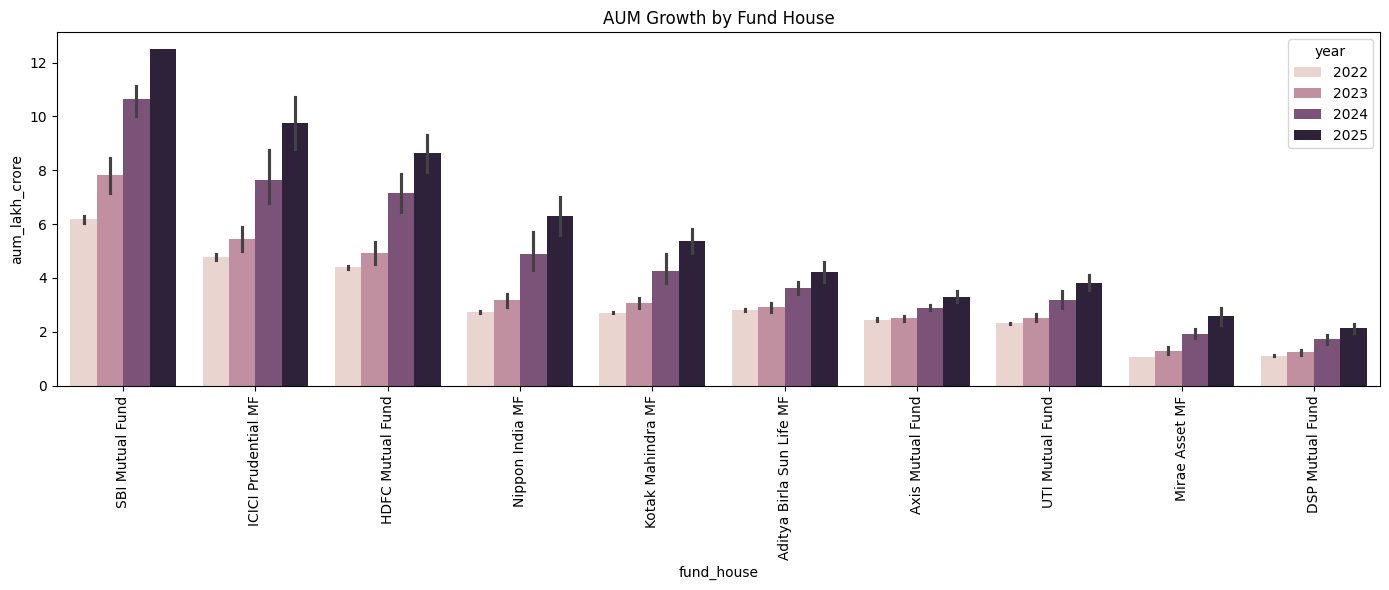

In [27]:
aum["year"] = aum["date"].dt.year

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)

plt.xticks(rotation=90)
plt.title("AUM Growth by Fund House")
plt.tight_layout()

plt.savefig("aum_growth.png")
plt.show()

In [28]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [29]:
print(sip["month"].head())

0    2022-01
1    2022-02
2    2022-03
3    2022-04
4    2022-05
Name: month, dtype: object


In [36]:
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows (2022-2025)"
)

max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=max_row["month"].strftime("%Y-%m-%d"),
    y=max_row["sip_inflow_crore"],
    text=f"Peak SIP ₹{max_row['sip_inflow_crore']:,.0f} Cr",
    showarrow=True
)
fig.write_image("sip_inflow_trend.png")
fig.show()


In [32]:
category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [33]:
category["category"].unique()

array(['Large Cap', 'Mid Cap', 'Small Cap', 'Flexi Cap',
       'Large & Mid Cap', 'ELSS', 'Value/Contra', 'Sectoral/Thematic',
       'Liquid', 'Short Duration', 'Gilt', 'Hybrid'], dtype=object)

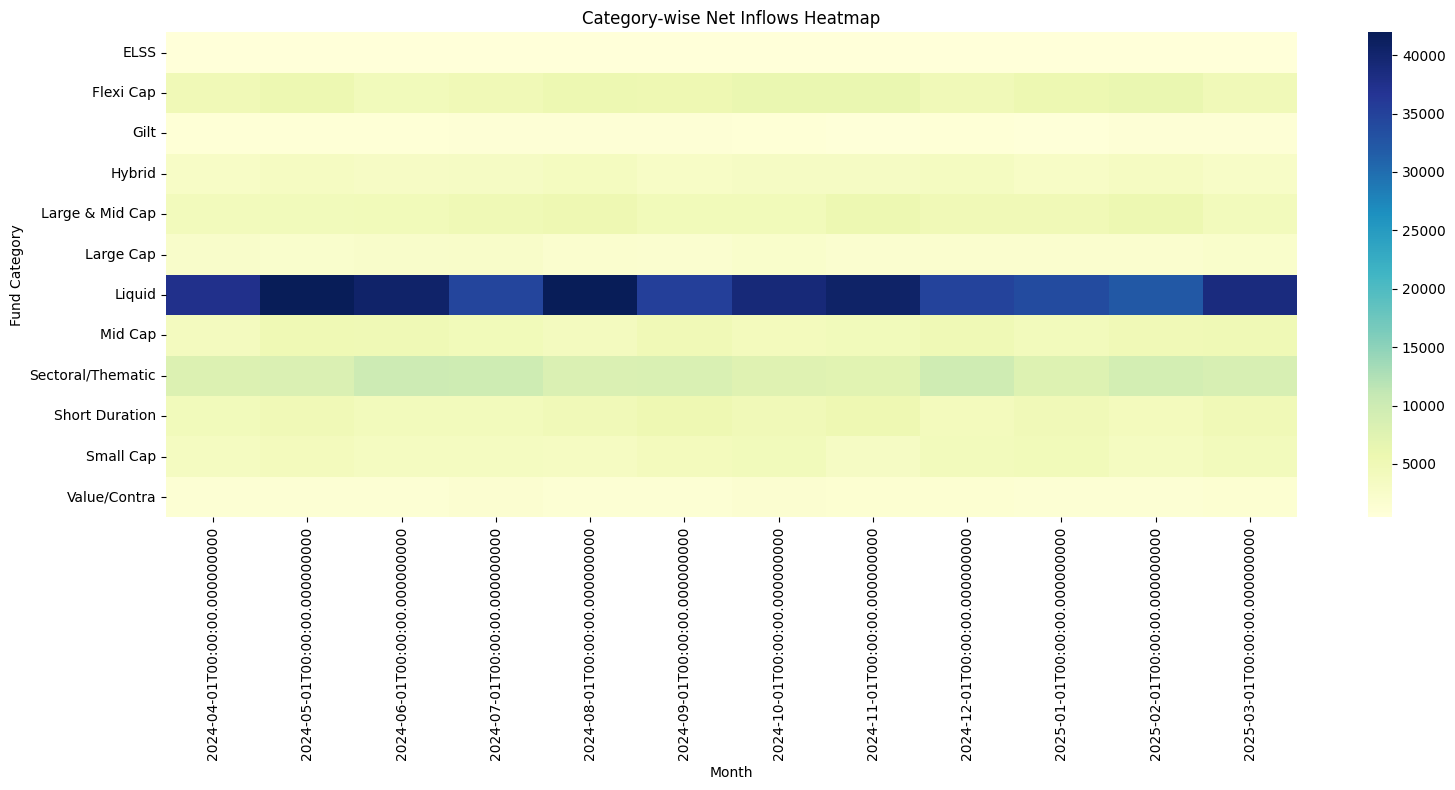

In [37]:
category["month"] = pd.to_datetime(category["month"])

heatmap_data = category.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore",
    aggfunc="sum"
)

plt.figure(figsize=(16,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=False
)

plt.title("Category-wise Net Inflows Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.savefig("category_inflow_heatmap.png")
plt.show()

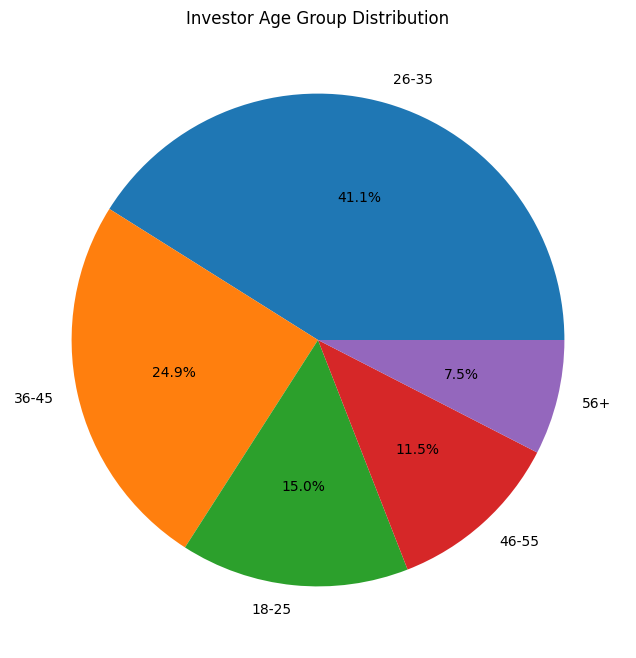

In [38]:
age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.savefig("age_group_distribution.png")
plt.show()

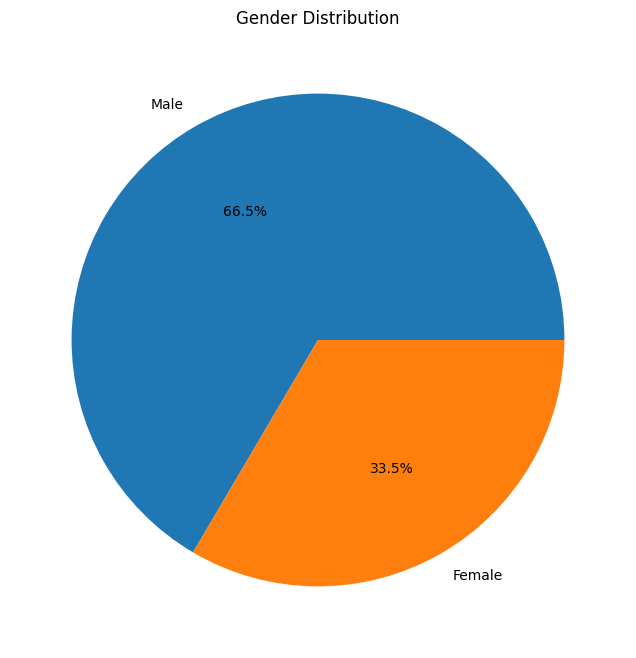

In [39]:
gender_counts = transactions["gender"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.savefig("gender_distribution.png")
plt.show()

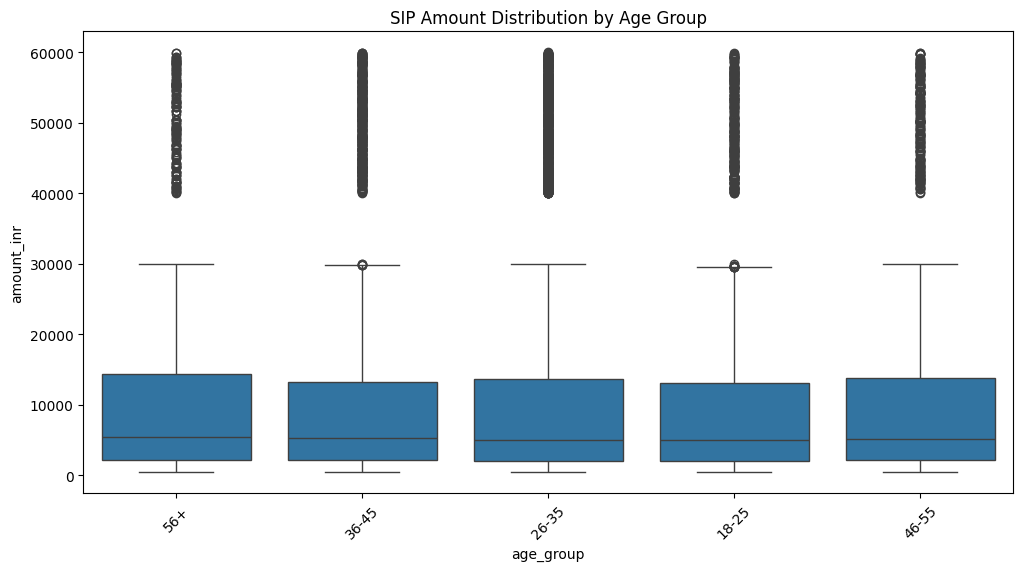

In [40]:
sip_txn = transactions[
    transactions["transaction_type"] == "SIP"
]

plt.figure(figsize=(12,6))

sns.boxplot(
    data=sip_txn,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xticks(rotation=45)

plt.savefig("sip_boxplot_agegroup.png")
plt.show()

In [41]:
transactions["city_tier"].value_counts()

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

In [42]:
transactions.groupby("state")["amount_inr"].sum().sort_values(ascending=False).head()

state
Punjab            315780459
Tamil Nadu        315177237
Madhya Pradesh    308312493
Rajasthan         298645822
Gujarat           298358940
Name: amount_inr, dtype: int64

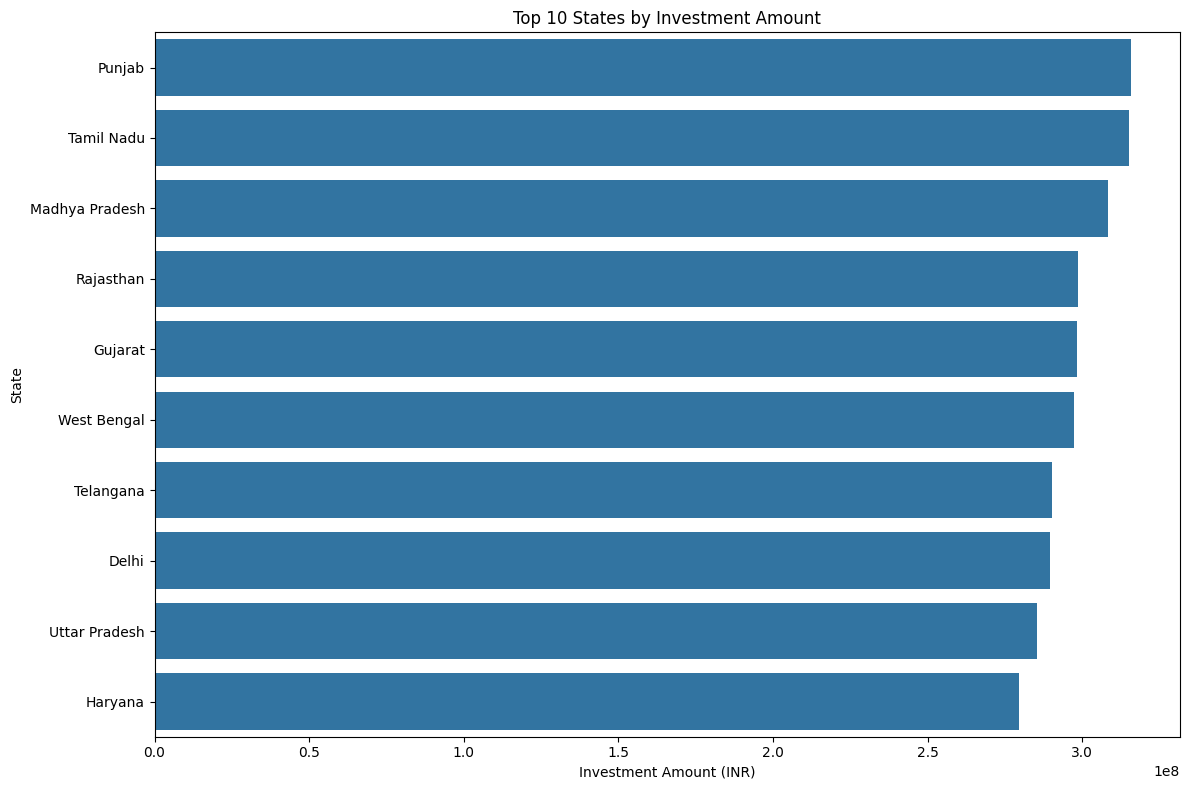

In [43]:
state_amount = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

sns.barplot(
    x=state_amount.values[:10],
    y=state_amount.index[:10]
)

plt.title("Top 10 States by Investment Amount")
plt.xlabel("Investment Amount (INR)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig("state_investment_distribution.png")
plt.show()

In [44]:
transactions["city_tier"].value_counts()

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

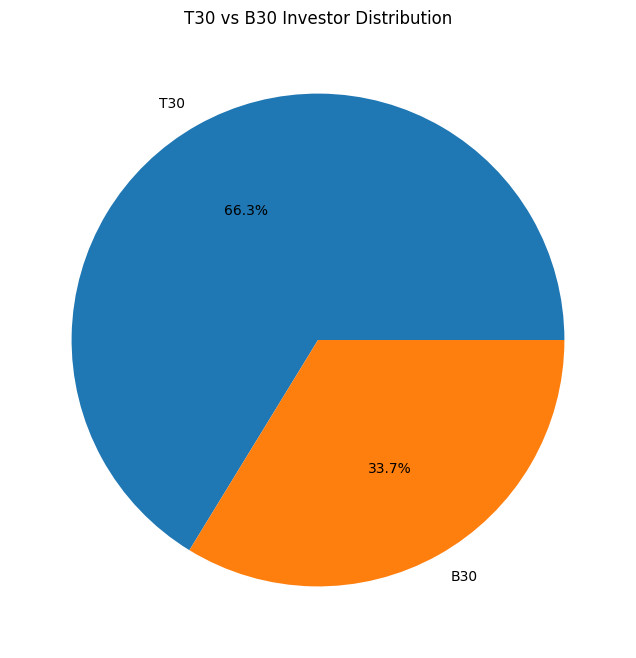

In [45]:
tier_counts = transactions["city_tier"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")

plt.savefig("t30_b30_distribution.png")
plt.show()

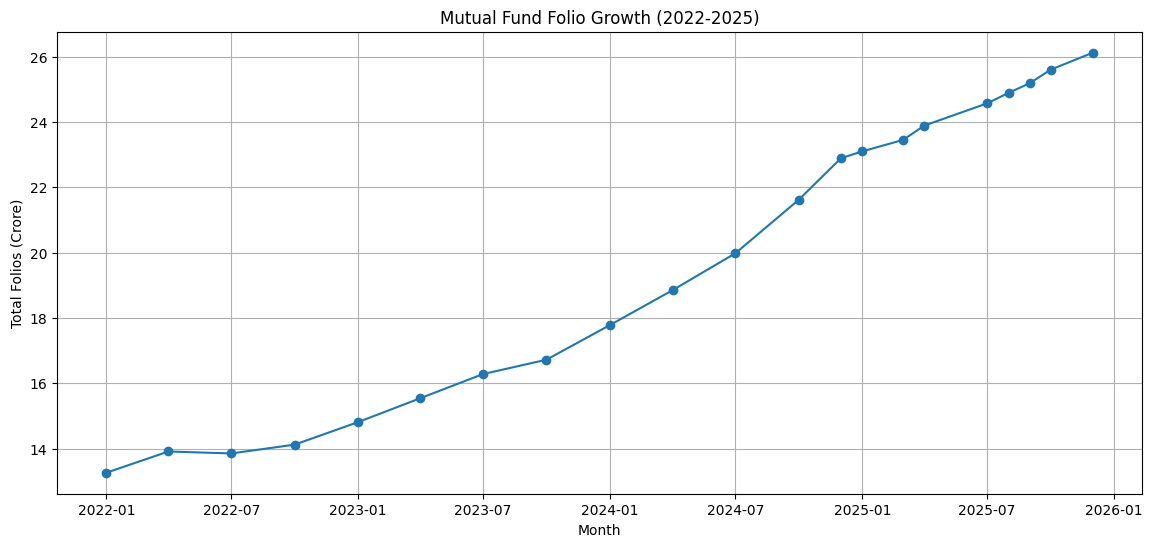

In [46]:
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(14,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Mutual Fund Folio Growth (2022-2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.savefig("folio_growth.png")
plt.show()

In [47]:
holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [48]:
holdings["sector"].value_counts().head(10)

sector
Banking           60
IT                40
Pharma            38
Automobile        33
Utilities         24
Infrastructure    22
FMCG              21
Telecom           15
Diversified       14
Energy            13
Name: count, dtype: int64

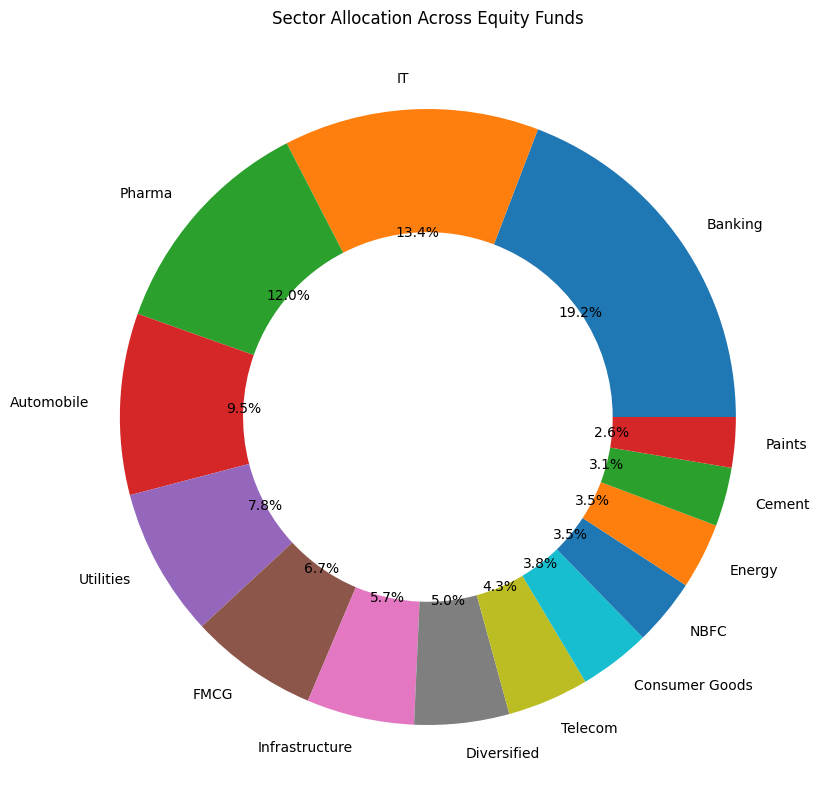

In [49]:
sector_weights = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,10))

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%",
    wedgeprops={"width":0.4}
)

plt.title("Sector Allocation Across Equity Funds")

plt.savefig("sector_allocation_donut.png")
plt.show()

In [50]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [51]:
performance[["amfi_code","scheme_name"]].head(10)

,amfi_code,scheme_name
0,119551,SBI Bluechip Fund - Regular Plan - Growth
1,119552,SBI Bluechip Fund - Direct Plan - Growth
2,119598,SBI Small Cap Fund - Regular Plan - Growth
3,119599,SBI Small Cap Fund - Direct Plan - Growth
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth
5,100016,HDFC Top 100 Fund - Regular Plan - Growth
6,125497,HDFC Top 100 Fund - Direct Plan - Growth
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
8,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth
9,100025,HDFC Short Term Debt Fund - Regular - Growth


### Insight 1
SIP inflows showed a consistent upward trend from 2022 to 2025, reaching an all-time high in December 2025.

Reference: sip_inflow_trend.png

In [55]:
selected_funds = [
    119551,
    119552,
    119598,
    119599,
    119120,
    100016,
    125497,
    100033,
    125498,
    100025
]

In [56]:
nav_corr = nav[nav["amfi_code"].isin(selected_funds)].copy()

nav_corr["date"] = pd.to_datetime(nav_corr["date"])

In [57]:
nav_pivot = nav_corr.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

nav_pivot.head()

amfi_code,100016,100025,100033,119120,119551,119552,119598,119599,125497,125498
date,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,42.1391,54.3856,58.4174,89.8738,96.4565,560.1443,117.5969
2022-01-04,515.0971,26.2234,105.9447,42.2508,54.3474,57.3480,88.5495,94.6512,560.7052,117.0077
2022-01-05,521.7239,26.2221,105.4800,42.4374,54.6869,57.0552,88.0925,94.5436,563.0884,116.4011
2022-01-06,515.7880,26.1728,104.9350,42.5901,55.4550,56.4224,88.5175,93.7944,561.0675,116.0861
2022-01-07,515.1639,26.2261,104.3318,42.4851,55.3692,57.2750,91.4235,89.6438,559.5420,114.6164


In [58]:
daily_returns = nav_pivot.pct_change()

daily_returns.head()

amfi_code,100016,100025,100033,119120,119551,119552,119598,119599,125497,125498
date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.010306,-0.003553,-0.013328,0.002651,-0.000702,-0.018306,-0.014735,-0.018716,0.001001,-0.005010
2022-01-05,0.012865,-0.000050,-0.004386,0.004416,0.006247,-0.005106,-0.005161,-0.001137,0.004250,-0.005184
2022-01-06,-0.011377,-0.001880,-0.005167,0.003598,0.014045,-0.011091,0.004824,-0.007924,-0.003589,-0.002706
2022-01-07,-0.001210,0.002036,-0.005748,-0.002465,-0.001547,0.015111,0.032830,-0.044252,-0.002719,-0.012660


In [59]:
corr_matrix = daily_returns.corr()

corr_matrix

amfi_code,100016,100025,100033,119120,119551,119552,119598,119599,125497,125498
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,-0.022521,0.040858,0.013663,-0.030296,-0.000007,0.047139,-0.016089
100025,0.045567,1.000000,0.002150,-0.040884,0.017017,-0.002803,-0.065019,-0.034061,0.011326,-0.025505
100033,-0.000006,0.002150,1.000000,-0.007166,-0.015559,-0.027471,0.006659,-0.028323,-0.025137,-0.011916
119120,-0.022521,-0.040884,-0.007166,1.000000,0.021601,-0.004003,0.018423,0.017795,-0.010542,-0.016315
119551,0.040858,0.017017,-0.015559,0.021601,1.000000,-0.006819,0.024409,-0.072559,0.016469,0.030454
119552,0.013663,-0.002803,-0.027471,-0.004003,-0.006819,1.000000,0.020754,-0.042415,0.027796,-0.052299
119598,-0.030296,-0.065019,0.006659,0.018423,0.024409,0.020754,1.000000,0.018187,-0.053278,0.018443
119599,-0.000007,-0.034061,-0.028323,0.017795,-0.072559,-0.042415,0.018187,1.000000,0.003347,0.041927
125497,0.047139,0.011326,-0.025137,-0.010542,0.016469,0.027796,-0.053278,0.003347,1.000000,0.027394


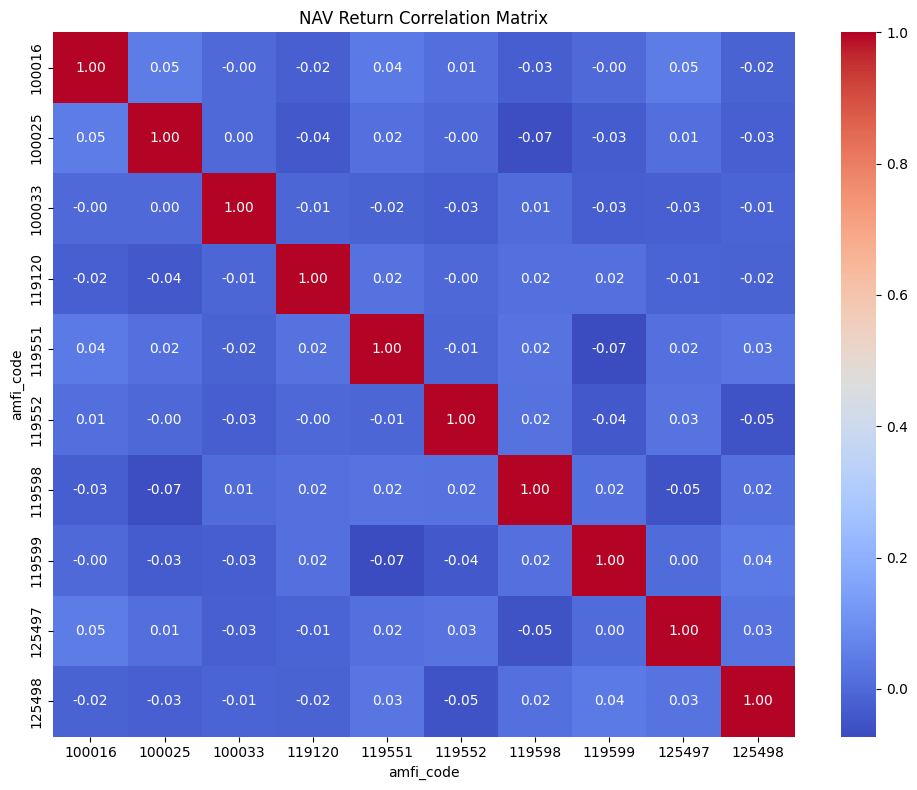

In [60]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("NAV Return Correlation Matrix")

plt.tight_layout()

plt.savefig("nav_correlation_heatmap.png")

plt.show()

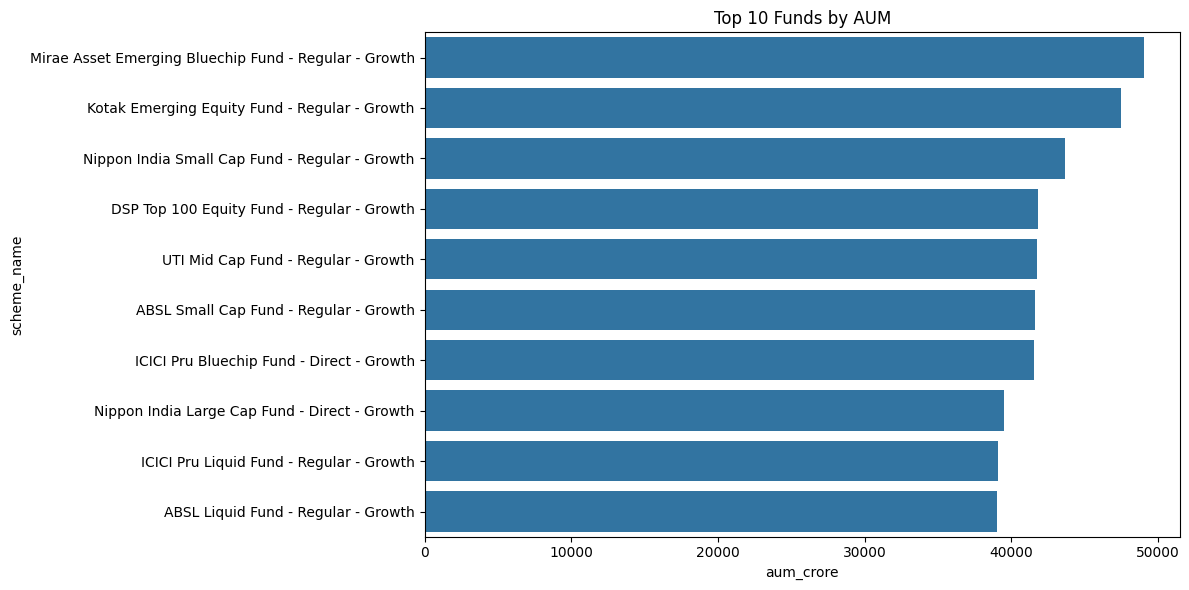

In [61]:
top_funds = performance.sort_values(
    "aum_crore",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_funds,
    x="aum_crore",
    y="scheme_name"
)

plt.title("Top 10 Funds by AUM")

plt.tight_layout()

plt.savefig("top10_aum.png")

plt.show()

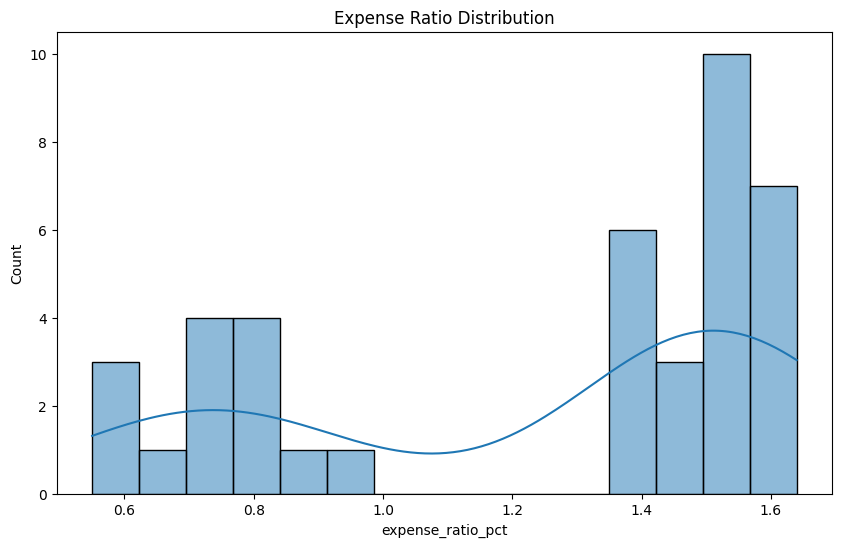

In [62]:
plt.figure(figsize=(10,6))

sns.histplot(
    performance["expense_ratio_pct"],
    bins=15,
    kde=True
)

plt.title("Expense Ratio Distribution")

plt.savefig("expense_ratio_distribution.png")

plt.show()

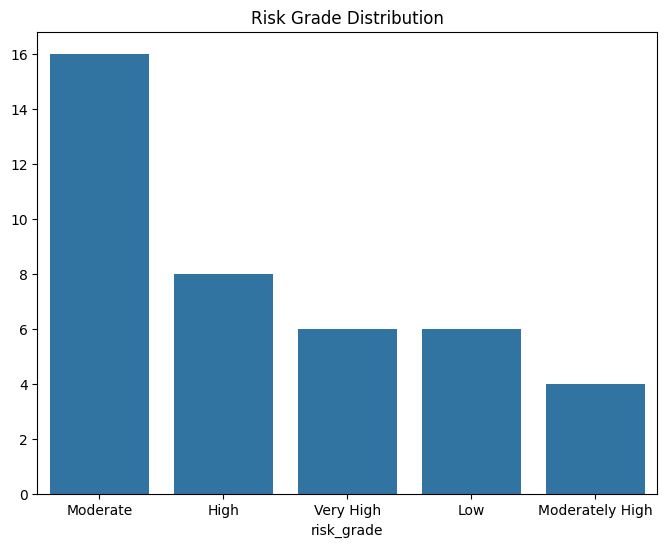

In [63]:
risk_counts = performance["risk_grade"].value_counts()

plt.figure(figsize=(8,6))

sns.barplot(
    x=risk_counts.index,
    y=risk_counts.values
)

plt.title("Risk Grade Distribution")

plt.savefig("risk_grade_distribution.png")

plt.show()

<Axes: xlabel='payment_mode', ylabel='count'>

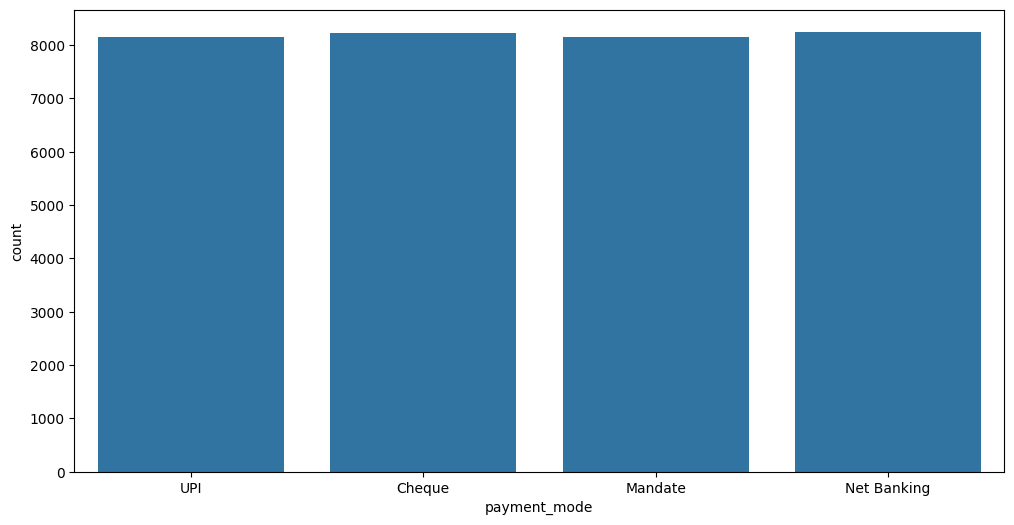

In [64]:
sns.countplot(data=transactions, x="payment_mode")